In [6]:
!pip install torch triton

layernorm-performance:
         N  Triton (GB/s)  Torch (GB/s)
0   1024.0     228.075260    218.226013
1   1536.0     240.683085    193.250270
2   2048.0     240.885834    177.109365
3   2560.0     235.688019    167.664849
4   3072.0     235.194615    164.939598
5   3584.0     239.933054    164.309451
6   4096.0     237.455993    164.663315
7   4608.0     237.103262    164.204895
8   5120.0     238.139535    164.168331
9   5632.0     237.762530    164.564638
10  6144.0     236.307695    164.383660
11  6656.0     236.047164    164.440838
12  7168.0     235.847054    164.493574
13  7680.0     236.197677    164.422327


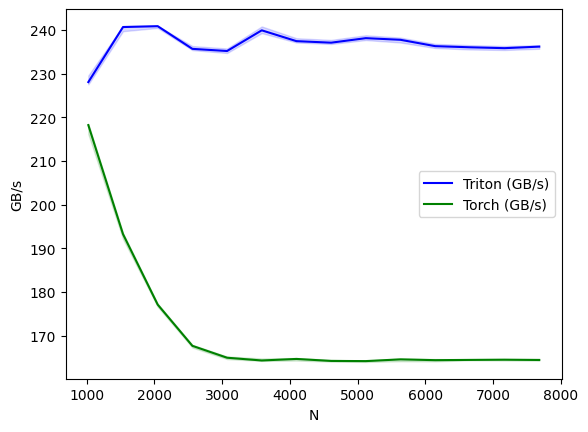

In [7]:
import torch
import triton
import triton.language as tl

# ====================================================================
# Forward Pass
# ====================================================================
def get_autotune_configs_fwd():
    return [
        triton.Config({}, num_warps=1),
        triton.Config({}, num_warps=2),
        triton.Config({}, num_warps=4),
        triton.Config({}, num_warps=8),
        triton.Config({}, num_warps=16),
    ]

@triton.autotune(
    configs=get_autotune_configs_fwd(),
    key=['N'],
)
@triton.jit
def layernorm_fwd_kernel(
    X_ptr, Y_ptr, W_ptr, B_ptr,
    Mean_ptr, Rstd_ptr,
    stride_x_row, stride_y_row,
    N, eps,
    BLOCK_SIZE_N: tl.constexpr
):
    row_idx = tl.program_id(0)

    X_row_ptr = X_ptr + row_idx * stride_x_row
    Y_row_ptr = Y_ptr + row_idx * stride_y_row

    cols = tl.arange(0, BLOCK_SIZE_N)
    mask = cols < N

    x = tl.load(X_row_ptr + cols, mask=mask, other=0.0).to(tl.float32)

    mean = tl.sum(x, axis=0) / N

    x_centered = tl.where(mask, x - mean, 0.0)
    var = tl.sum(x_centered * x_centered, axis=0) / N
    rstd = 1.0 / tl.sqrt(var + eps)

    tl.store(Mean_ptr + row_idx, mean)
    tl.store(Rstd_ptr + row_idx, rstd)

    x_hat = x_centered * rstd

    w = tl.load(W_ptr + cols, mask=mask, other=0.0).to(tl.float32)
    b = tl.load(B_ptr + cols, mask=mask, other=0.0).to(tl.float32)

    y = x_hat * w + b

    tl.store(Y_row_ptr + cols, y, mask=mask)

# ====================================================================
# Backward Pass
# ====================================================================
def get_autotune_configs_bwd():
    configs = []
    for block_m in [1, 2, 4, 8, 16]:
        for num_warps in [2, 4, 8, 16]:
            configs.append(triton.Config({'BLOCK_SIZE_M': block_m}, num_warps=num_warps))
    return configs

@triton.autotune(
    configs=get_autotune_configs_bwd(),
    key=['M', 'N'],
    reset_to_zero=['dW_ptr', 'dB_ptr'],
)
@triton.jit
def layernorm_bwd_kernel(
    dY_ptr, X_ptr, W_ptr,
    Mean_ptr, Rstd_ptr,
    dX_ptr, dW_ptr, dB_ptr,
    stride_dy_row, stride_x_row, stride_dx_row,
    M, N,
    BLOCK_SIZE_M: tl.constexpr,
    BLOCK_SIZE_N: tl.constexpr
):
    pid = tl.program_id(0)
    row_start = pid * BLOCK_SIZE_M

    cols = tl.arange(0, BLOCK_SIZE_N)
    mask_n = cols < N

    w = tl.load(W_ptr + cols, mask=mask_n, other=0.0).to(tl.float32)

    dw_local = tl.zeros((BLOCK_SIZE_N,), dtype=tl.float32)
    db_local = tl.zeros((BLOCK_SIZE_N,), dtype=tl.float32)

    for m in range(0, BLOCK_SIZE_M):
        row_idx = row_start + m
        if row_idx < M:
            dy_ptrs = dY_ptr + row_idx * stride_dy_row + cols
            x_ptrs = X_ptr + row_idx * stride_x_row + cols
            dx_ptrs = dX_ptr + row_idx * stride_dx_row + cols

            dy = tl.load(dy_ptrs, mask=mask_n, other=0.0).to(tl.float32)
            x = tl.load(x_ptrs, mask=mask_n, other=0.0).to(tl.float32)
            mean = tl.load(Mean_ptr + row_idx).to(tl.float32)
            rstd = tl.load(Rstd_ptr + row_idx).to(tl.float32)

            x_hat = (x - mean) * rstd

            dw_local += dy * x_hat
            db_local += dy

            dx_hat = dy * w
            c1 = tl.sum(dx_hat, axis=0) / N
            c2 = tl.sum(dx_hat * x_hat, axis=0) / N

            dx = rstd * (dx_hat - c1 - x_hat * c2)

            tl.store(dx_ptrs, dx, mask=mask_n)

    tl.atomic_add(dW_ptr + cols, dw_local, mask=mask_n)
    tl.atomic_add(dB_ptr + cols, db_local, mask=mask_n)

# ====================================================================
# PyTorch Wrapper
# ====================================================================
class TritonLayerNorm(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, weight, bias, eps=1e-5):
        x = x.contiguous()
        weight = weight.contiguous()
        bias = bias.contiguous()

        M, N = x.shape
        y = torch.empty_like(x)
        mean = torch.empty((M,), dtype=torch.float32, device=x.device)
        rstd = torch.empty((M,), dtype=torch.float32, device=x.device)

        BLOCK_SIZE_N = triton.next_power_of_2(N)

        grid = lambda meta: (M, )
        layernorm_fwd_kernel[grid](
            x, y, weight, bias,
            mean, rstd,
            x.stride(0), y.stride(0),
            N, eps,
            BLOCK_SIZE_N=BLOCK_SIZE_N,
        )

        ctx.save_for_backward(x, weight, mean, rstd)
        ctx.eps = eps
        ctx.M = M
        ctx.N = N
        ctx.BLOCK_SIZE_N = BLOCK_SIZE_N

        return y

    @staticmethod
    def backward(ctx, dy):
        dy = dy.contiguous()
        x, weight, mean, rstd = ctx.saved_tensors
        M, N = ctx.M, ctx.N

        dx = torch.empty_like(x)
        dw = torch.zeros_like(weight)
        db = torch.zeros_like(weight)

        def grid(meta):
            return (triton.cdiv(M, meta['BLOCK_SIZE_M']),)

        layernorm_bwd_kernel[grid](
            dy, x, weight,
            mean, rstd,
            dx, dw, db,
            dy.stride(0), x.stride(0), dx.stride(0),
            M, N,
            BLOCK_SIZE_N=ctx.BLOCK_SIZE_N
        )

        return dx, dw, db, None

# ====================================================================
# Reference Implementation
# ====================================================================
def layernorm_forward_torch(x: torch.Tensor, weight: torch.Tensor, bias: torch.Tensor, eps: float = 1e-5):
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, unbiased=False, keepdim=True)
    rstd = 1.0 / torch.sqrt(var + eps)
    x_hat = (x - mean) * rstd
    return x_hat * weight + bias

# ====================================================================
# Correctness Check
# ====================================================================
def test_correctness():
    M, N = 128, 1024
    x = torch.randn(M, N, device='cuda', requires_grad=True)
    w = torch.randn(N, device='cuda', requires_grad=True)
    b = torch.randn(N, device='cuda', requires_grad=True)
    dy = torch.randn(M, N, device='cuda')

    y_triton = TritonLayerNorm.apply(x, w, b, 1e-5)
    y_triton.backward(dy, retain_graph=True)
    dx_triton, dw_triton, db_triton = x.grad.clone(), w.grad.clone(), b.grad.clone()

    x.grad, w.grad, b.grad = None, None, None

    y_torch = layernorm_forward_torch(x, w, b, 1e-5)
    y_torch.backward(dy)
    dx_torch, dw_torch, db_torch = x.grad.clone(), w.grad.clone(), b.grad.clone()

    torch.testing.assert_close(y_triton, y_torch, atol=1e-3, rtol=1e-3)
    torch.testing.assert_close(dx_triton, dx_torch, atol=1e-3, rtol=1e-3)
    torch.testing.assert_close(dw_triton, dw_torch, atol=1e-2, rtol=1e-2)
    torch.testing.assert_close(db_triton, db_torch, atol=1e-2, rtol=1e-2)

# ====================================================================
# Benchmarks
# ====================================================================
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['N'],
        x_vals=[512 * i for i in range(2, 16)],
        line_arg='provider',
        line_vals=['triton', 'torch'],
        line_names=['Triton', 'Torch'],
        styles=[('blue', '-'), ('green', '-')],
        ylabel='GB/s',
        plot_name='layernorm-performance',
        args={'M': 4096},
    )
)
def benchmark(M, N, provider):
    x = torch.randn(M, N, device='cuda', dtype=torch.float32, requires_grad=True)
    w = torch.randn(N, device='cuda', dtype=torch.float32, requires_grad=True)
    b = torch.randn(N, device='cuda', dtype=torch.float32, requires_grad=True)
    eps = 1e-5

    quantiles = [0.5, 0.2, 0.8]

    if provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: torch.nn.functional.layer_norm(x, (N,), w, b, eps),
            quantiles=quantiles
        )
    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: TritonLayerNorm.apply(x, w, b, eps),
            quantiles=quantiles
        )

    gbps = lambda ms: (2 * x.numel() * x.element_size()) / ms * 1e-6
    return gbps(ms), gbps(max_ms), gbps(min_ms)

if __name__ == "__main__":
    test_correctness()
    benchmark.run(print_data=True, show_plots=False)